# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [ ]:
#
#
#
#
# Your code to develop AI model for malware classification.
# Hint: Use the example code provided in previous lab.
#
#
#
#

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.

# Task
The user wants to detect Android malware by loading the "Android Malware Dataset for Machine Learning" from Kaggle (https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning), preprocessing the data, training and evaluating at least three different AI models (Logistic Regression, Random Forest, and XGBoost Classifier), and then comparing their performance using accuracy, precision, recall, F1-score, and confusion matrices, and finally visualizing the comparison.

## Load Dataset

### Subtask:
Load the Android Malware Dataset from Kaggle. This step will involve downloading the dataset (if not already present) and loading it into a pandas DataFrame.


**Reasoning**:
First, I need to ensure that the `kaggle` library is installed to interact with the Kaggle API for downloading the dataset.



In [ ]:
# This cell imports the tools we need for loading data, training models,
# checking model performance, and drawing the final graph.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
# This cell loads the Android malware dataset into Python
# and removes any extra spaces from the column names.

df = pd.read_csv("Android_Malware.csv", low_memory=False)
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

df.head()

Dataset loaded successfully.
Original shape: (355630, 86)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,172.217.6.202-10.42.0.211-443-50004-6,10.42.0.211,50004,172.217.6.202,443.0,6.0,13/06/2017 11:52:39,37027,1,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
1,1,172.217.6.202-10.42.0.211-443-35455-6,10.42.0.211,35455,172.217.6.202,443.0,6.0,13/06/2017 11:52:39,36653,1,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
2,2,131.253.61.68-10.42.0.211-443-51775-6,10.42.0.211,51775,131.253.61.68,443.0,6.0,13/06/2017 11:52:42,534099,8,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
3,3,131.253.61.68-10.42.0.211-443-51775-6,10.42.0.211,51775,131.253.61.68,443.0,6.0,13/06/2017 11:52:43,9309,3,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
4,4,131.253.61.68-10.42.0.211-443-51776-6,10.42.0.211,51776,131.253.61.68,443.0,6.0,13/06/2017 11:52:42,19890496,8,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware


In [ ]:
# This cell takes a smaller sample from the full dataset
# so the models train faster and the notebook runs more smoothly.

df = df.sample(n=5000, random_state=42)

print("Sampled dataset shape:", df.shape)
df.head()

Sampled dataset shape: (5000, 86)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
67071,1338,151.101.46.2-10.42.0.151-443-49475-6,10.42.0.151,49475,151.101.46.2,443.0,6.0,14/06/2017 06:53:24,300,3,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
2727,360,10.42.0.211-121.12.98.62-53147-80-6,10.42.0.211,53147,121.12.98.62,80.0,6.0,13/06/2017 02:22:23,12846672,10,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
121589,1518,172.217.3.106-10.42.0.211-443-35767-6,10.42.0.211,35767,172.217.3.106,443.0,6.0,15/06/2017 02:13:23,247756,9,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Adware
150251,2808,10.42.0.151-10.42.0.1-40667-53-17,10.42.0.151,40667,10.42.0.1,53.0,17.0,22/06/2017 12:28:21,61589,1,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Scareware
150919,3476,10.42.0.151-64.95.32.57-54594-443-6,10.42.0.151,54594,64.95.32.57,443.0,6.0,22/06/2017 12:56:32,94904,1,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Android_Scareware


In [ ]:
# This cell shows all the column names in the dataset
# so we can confirm which one is the target column.

print(df.columns.tolist())

['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag

In [ ]:
# This cell tells Python which column contains the class labels
# that we want the models to predict.

target_column = "Label"

In [ ]:
# This cell gives a quick summary of the dataset,
# including data types, missing values, and class distribution.

print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df[target_column].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 67071 to 119328
Data columns (total 86 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   5000 non-null   int64  
 1   Flow ID                      5000 non-null   object 
 2   Source IP                    5000 non-null   object 
 3   Source Port                  5000 non-null   int64  
 4   Destination IP               5000 non-null   object 
 5   Destination Port             5000 non-null   float64
 6   Protocol                     5000 non-null   float64
 7   Timestamp                    5000 non-null   object 
 8   Flow Duration                5000 non-null   int64  
 9   Total Fwd Packets            5000 non-null   int64  
 10  Total Backward Packets       5000 non-null   int64  
 11  Total Length of Fwd Packets  5000 non-null   float64
 12  Total Length of Bwd Packets  5000 non-null   float64
 13  Fwd Packet Length

In [ ]:
# This cell splits the dataset into input features and the target label.
# X contains the input data, and y contains the answers.

X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 85)
Target shape: (5000,)


In [ ]:
# This cell changes any text-based columns into numbers
# because machine learning models work with numeric data.

for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Remaining text columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Remaining text columns:
[]


In [ ]:
# This cell changes the target labels into numeric form
# so the models can learn from them.

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Unique encoded classes:")
print(np.unique(y))

Unique encoded classes:
[0 1 2 3]


In [ ]:
# This cell creates an empty dictionary
# where we will store the performance scores of each model.

model_results = {}

In [ ]:
# This cell builds the Logistic Regression model,
# trains it on the training data, makes predictions,
# and stores its performance scores.

log_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, average="weighted")
log_recall = recall_score(y_test, y_pred_log, average="weighted")
log_f1 = f1_score(y_test, y_pred_log, average="weighted")

model_results["Logistic Regression"] = {
    "Accuracy": log_accuracy,
    "Precision": log_precision,
    "Recall": log_recall,
    "F1 Score": log_f1
}

print("Logistic Regression Results")
print("Accuracy:", log_accuracy)
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.977
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       415
           1       1.00      1.00      1.00       194
           2       0.98      0.98      0.98       325
           3       0.80      0.89      0.84        66

    accuracy                           0.98      1000
   macro avg       0.94      0.96      0.95      1000
weighted avg       0.98      0.98      0.98      1000



In [ ]:
# This cell builds the Random Forest model,
# trains it, makes predictions, and stores its results.

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

model_results["Random Forest"] = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
}

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       415
           1       1.00      1.00      1.00       194
           2       0.98      1.00      0.99       325
           3       1.00      0.92      0.96        66

    accuracy                           0.99      1000
   macro avg       1.00      0.98      0.99      1000
weighted avg       1.00      0.99      0.99      1000



In [ ]:
# This cell builds the Gradient Boosting model,
# trains it, makes predictions, and stores its results.

gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("classifier", GradientBoostingClassifier(n_estimators=50, random_state=42))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, average="weighted")
gb_recall = recall_score(y_test, y_pred_gb, average="weighted")
gb_f1 = f1_score(y_test, y_pred_gb, average="weighted")

model_results["Gradient Boosting"] = {
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1 Score": gb_f1
}

print("Gradient Boosting Results")
print("Accuracy:", gb_accuracy)
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       415
           1       1.00      1.00      1.00       194
           2       1.00      1.00      1.00       325
           3       1.00      1.00      1.00        66

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# This cell turns the saved model results into a table
# so we can compare them more easily.

results_df = pd.DataFrame(model_results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.977,0.978555,0.977,0.977571
Random Forest,0.995,0.995076,0.995,0.994921
Gradient Boosting,1.000,1.000000,1.000,1.000000


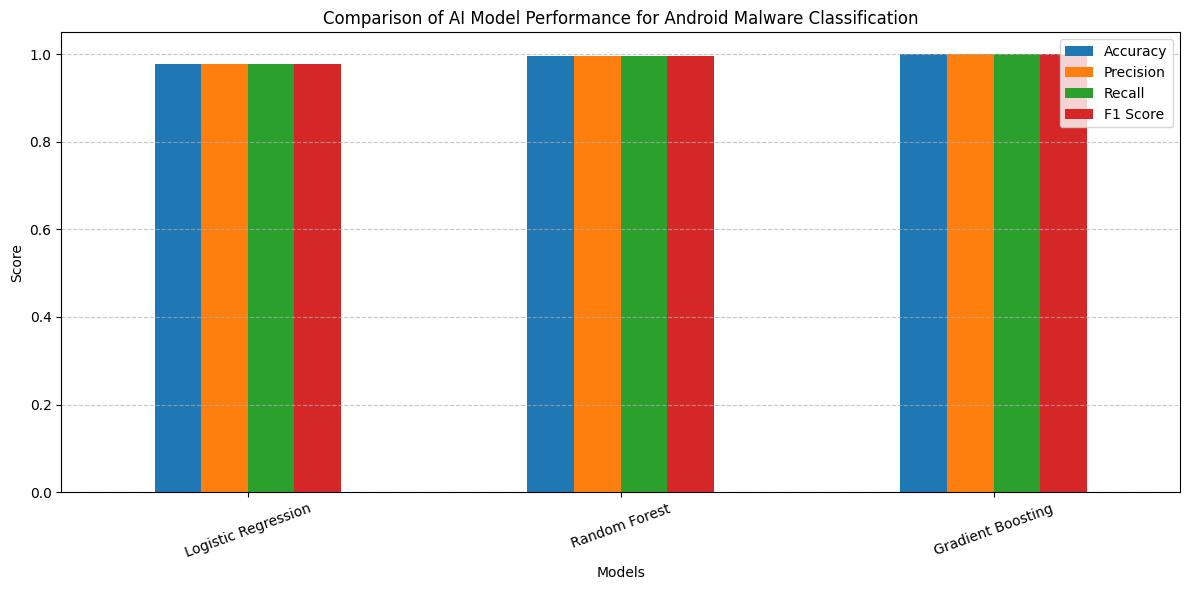

In [ ]:
# This cell draws a bar chart comparing the models
# using accuracy, precision, recall, and F1 score.

results_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of AI Model Performance for Android Malware Classification")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# This cell finds the model with the highest accuracy
# and prints its name and score.

best_model = results_df["Accuracy"].idxmax()
best_score = results_df["Accuracy"].max()

print(f"The best performing model based on accuracy is {best_model} with a score of {best_score:.4f}.")

The best performing model based on accuracy is Gradient Boosting with a score of 1.0000.
